# SEIRV Demo — Single Season (Step E 갱신)

신규 모델 구조:
- **5 compartments**: S / V / E / I / R (J 제거, V 추가)
- **4채널 FOI**: home (+ spillover) / work / school / other
- **정책 변수**: p_school, p_work (스칼라)
- **백신**: VE=0.5, Gaussian 시간 분포 (peak ISO 42주)
- **경제활동 ρ**: kt_data.build_rho_matrix (시도×연령)

**상위 문서**: `docs/PAPER_OUTLINE.md`, `docs/STAGE2_DESIGN.md`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from kt_epimodel.model.parameters import (
    CalibrationParameters,
    ModelParameters,
    PolicyParameters,
    AGE_LABELS_15,
)
from kt_epimodel.simulation.runner import (
    compare_scenarios,
    run_scenarios,
    run_single_season,
)

OUT = Path('../outputs'); OUT.mkdir(exist_ok=True)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## 1. Baseline (β default = 0.05)

5 compartment + 백신 시계열 확인.

In [2]:
data = run_single_season(t_span=(0, 224))
result = data['result']
pop = data['pop_15']
totals = result.total_by_compartment()    # (n_t, 5)

Run: 202301/weekday, t_span=(0, 224)
  pop:        25,990,466
  initial I:  5,770
  initial R:  0
  initial V:  0
  success:    True
  final AR:   3.5965%
  final vax:  29.2456%


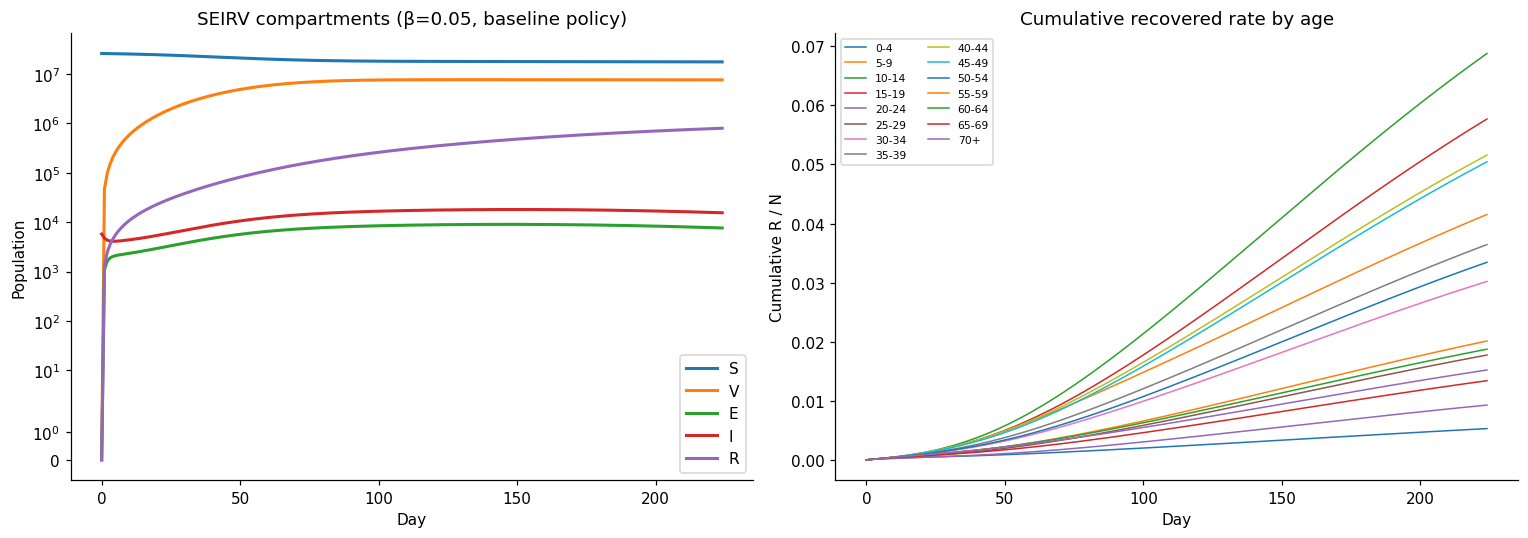

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = ['S', 'V', 'E', 'I', 'R']
for c, lbl in enumerate(labels):
    axes[0].plot(result.t, totals[:, c], label=lbl, linewidth=2)
axes[0].set_xlabel('Day'); axes[0].set_ylabel('Population')
axes[0].set_title('SEIRV compartments (β=0.05, baseline policy)')
axes[0].set_yscale('symlog')
axes[0].legend()

# Attack rate by age
ar_age_t = result.total_by_age()[:, 4, :]  # R compartment
pop_by_age = pop.sum(axis=1)
ar_by_age = ar_age_t / pop_by_age[None, :]
for a, lab in enumerate(AGE_LABELS_15):
    axes[1].plot(result.t, ar_by_age[:, a], label=lab, linewidth=1.0)
axes[1].set_xlabel('Day'); axes[1].set_ylabel('Cumulative R / N')
axes[1].set_title('Cumulative recovered rate by age')
axes[1].legend(loc='upper left', fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(OUT / 'demo_baseline_seirv.png', dpi=120)
plt.show()

## 2. 백신 V 시계열

Gaussian 분포: peak ISO 42주 (시즌 시작 + 42일), σ = 28일.

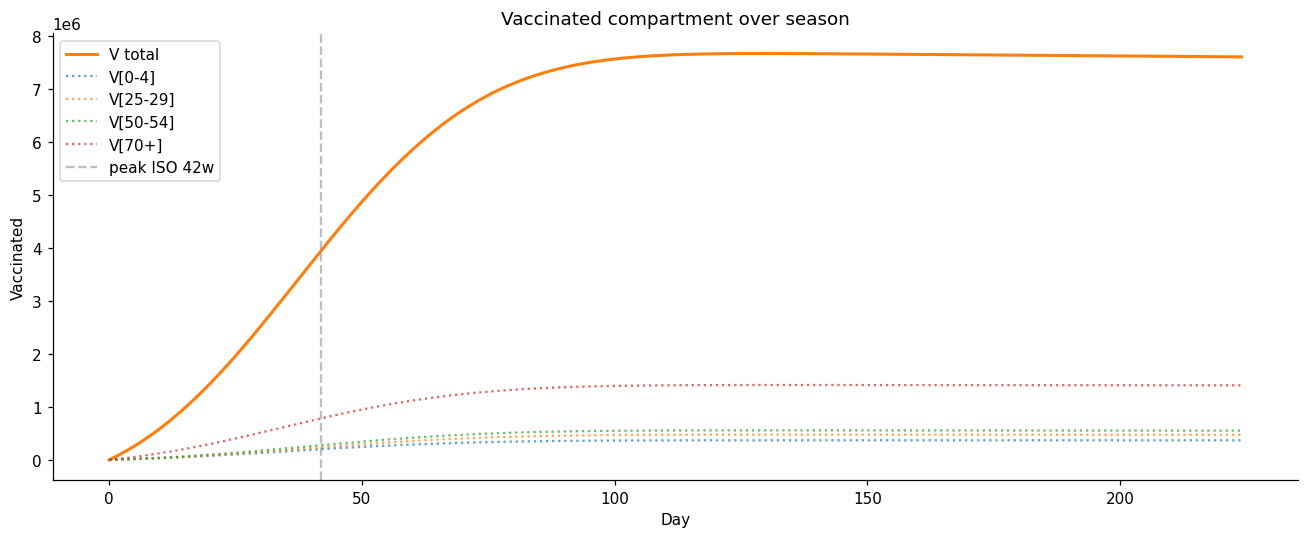

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
V_total = result.vaccinated_total()
ax.plot(result.t, V_total, color='C1', linewidth=2, label='V total')
# 연령별
for a in (0, 5, 10, 14):    # 0-4, 25-29, 50-54, 70+
    V_age = result.states[:, 1, a].sum(axis=1)
    ax.plot(result.t, V_age, label=f'V[{AGE_LABELS_15[a]}]', linestyle=':', alpha=0.7)
ax.axvline(42, color='gray', linestyle='--', alpha=0.5, label='peak ISO 42w')
ax.set_xlabel('Day'); ax.set_ylabel('Vaccinated')
ax.set_title('Vaccinated compartment over season')
ax.legend()
plt.tight_layout()
plt.savefig(OUT / 'demo_vaccinated.png', dpi=120)
plt.show()

## 3. 정책 시나리오 비교 (β 강화)

baseline β=0.05 는 outbreak 약함. β=0.5 로 가시화 (Stage 3 calibration 전 정성 점검).

In [5]:
base = ModelParameters(
    calibration=CalibrationParameters(
        beta_h=0.5, beta_w=0.5, beta_s=0.5, beta_o=0.5,
        phi=np.ones(15), gamma_report=0.5,
    ),
)
scenarios = {
    'baseline':       PolicyParameters.baseline(),
    'school_closure': PolicyParameters.school_closure(),
    'sick_leave':     PolicyParameters.sick_leave_enhanced(),
    'comprehensive':  PolicyParameters.comprehensive(),
}
results = run_scenarios(scenarios, base_params=base, t_span=(0, 120))


=== Scenario: baseline ===
Run: 202301/weekday, t_span=(0, 120)
  pop:        25,990,466
  initial I:  5,770
  initial R:  0
  initial V:  0
  success:    True
  final AR:   99.7231%
  final vax:  0.0832%

=== Scenario: school_closure ===
Run: 202301/weekday, t_span=(0, 120)
  pop:        25,990,466
  initial I:  5,770
  initial R:  0
  initial V:  0
  success:    True
  final AR:   99.4544%
  final vax:  0.1706%

=== Scenario: sick_leave ===
Run: 202301/weekday, t_span=(0, 120)
  pop:        25,990,466
  initial I:  5,770
  initial R:  0
  initial V:  0
  success:    True
  final AR:   99.7367%
  final vax:  0.0828%

=== Scenario: comprehensive ===
Run: 202301/weekday, t_span=(0, 120)
  pop:        25,990,466
  initial I:  5,770
  initial R:  0
  initial V:  0
  success:    True
  final AR:   99.5102%
  final vax:  0.1579%


In [6]:
summary = compare_scenarios(results)
print(summary)

shape: (4, 6)
┌────────────────┬───────────────────┬──────────┬──────────────────┬─────────────────┬──────────┐
│ scenario       ┆ final_attack_rate ┆ final_R  ┆ final_vaccinated ┆ peak_infectious ┆ peak_day │
│ ---            ┆ ---               ┆ ---      ┆ ---              ┆ ---             ┆ ---      │
│ str            ┆ f64               ┆ f64      ┆ f64              ┆ f64             ┆ f64      │
╞════════════════╪═══════════════════╪══════════╪══════════════════╪═════════════════╪══════════╡
│ baseline       ┆ 0.998081          ┆ 2.5941e7 ┆ 0.000832         ┆ 1.0116e7        ┆ 13.0     │
│ school_closure ┆ 0.996818          ┆ 2.5908e7 ┆ 0.001706         ┆ 9.6199e6        ┆ 15.0     │
│ sick_leave     ┆ 0.99816           ┆ 2.5943e7 ┆ 0.000828         ┆ 9.9524e6        ┆ 13.0     │
│ comprehensive  ┆ 0.997114          ┆ 2.5915e7 ┆ 0.001579         ┆ 9.5363e6        ┆ 15.0     │
└────────────────┴───────────────────┴──────────┴──────────────────┴─────────────────┴──────────┘


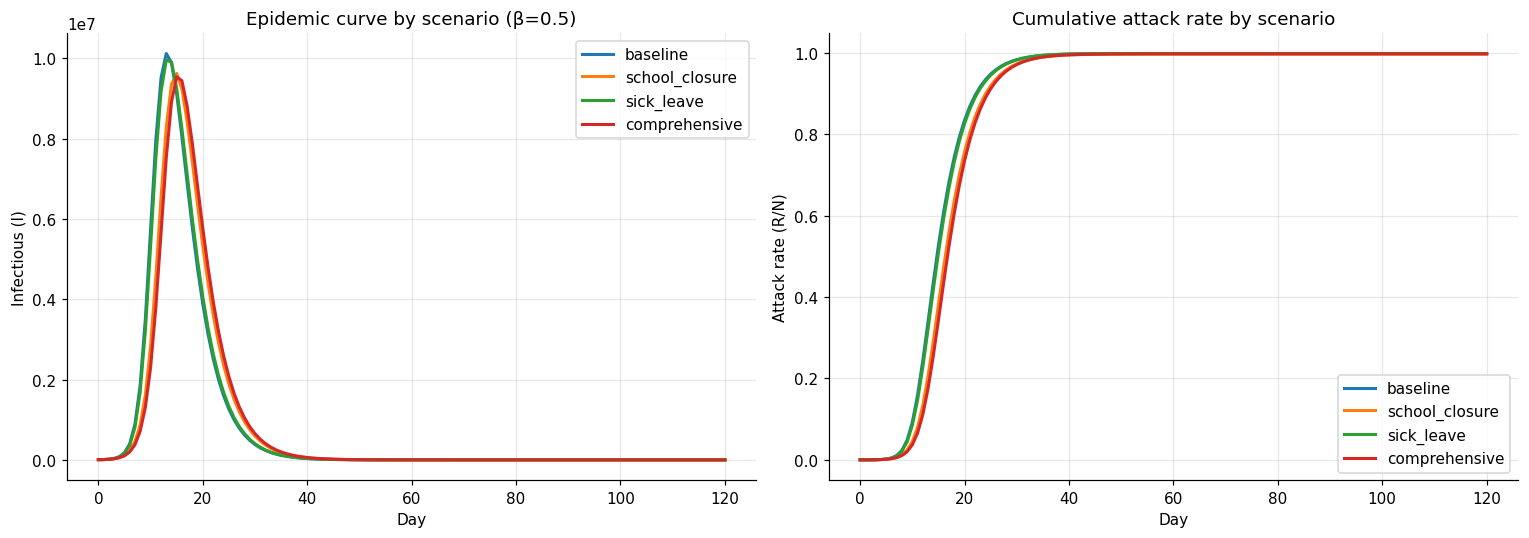

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, data in results.items():
    totals = data['result'].total_by_compartment()
    t = data['result'].t
    axes[0].plot(t, totals[:, 3], label=name, linewidth=2)
axes[0].set_xlabel('Day'); axes[0].set_ylabel('Infectious (I)')
axes[0].set_title('Epidemic curve by scenario (β=0.5)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

for name, data in results.items():
    totals = data['result'].total_by_compartment()
    t = data['result'].t
    axes[1].plot(t, totals[:, 4] / data['pop_15'].sum(),
                 label=name, linewidth=2)
axes[1].set_xlabel('Day'); axes[1].set_ylabel('Attack rate (R/N)')
axes[1].set_title('Cumulative attack rate by scenario')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / 'demo_scenarios_seirv.png', dpi=120)
plt.show()

## 4. 결론 + 다음 단계

**확인**:
- 5 compartment SEIRV 모델 인구 보존
- 백신 Gaussian 시간 분포 동작 (peak day 42 근방 유입)
- 정책 시나리오 정성 차이 (학교 휴교 → 학생 감염 ↓, 가구 spillover ↑)
- attack rate = (I+R)/N (V 제외)

**한계** (Stage 3 calibration 에서 해결):
- baseline β=0.05 약함 — ILI fit 필요
- φ_a 모두 1 — 연령별 차이 미반영
- λ_*(t) 시간 가변 미적용 (Step F+ 확장)

**다음 단계**:
1. **Stage 3**: ILI 2018-2019 / 2022-2023 으로 β_h, β_w, β_s, β_o, φ_a, γ_report 추정 (Nelder-Mead)
2. **Stage 4**: 4 정책 시나리오 ICER 평가